<a href="https://colab.research.google.com/github/itz-mehraz/bengali-social-media-scam-detection/blob/main/notebooks/social_media_scam_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Social Media Scam Detection Using Machine Learning

### Thesis Project Overview
This notebook presents a machine learning-based approach for detecting scam-related job and social media posts using English and Bengali text data. The workflow includes data loading, preprocessing, feature extraction, model training, evaluation, and result visualization.

In [3]:
# essential libraries import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from google.colab import files

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
# dataset files upload
uploaded = files.upload()
print("\nUploaded files:")
for file_name in uploaded.keys():
    print("-", file_name)

Saving fake_job_postings.csv to fake_job_postings.csv

Uploaded files:
- fake_job_postings.csv


In [5]:
uploaded = files.upload()
print("\nUploaded files:")
for file_name in uploaded.keys():
    print("-", file_name)

Saving fb_job_post_dataset.csv to fb_job_post_dataset.csv

Uploaded files:
- fb_job_post_dataset.csv


## Step 2: Data Loading and Initial Exploration

In this step, both datasets are loaded and explored to understand their structure, class distribution, and suitability for machine learning-based scam detection.


In [6]:
# Loading both datasets

data = pd.read_csv("fake_job_postings.csv")
fb_data = pd.read_csv("fb_job_post_dataset.csv")

print("Main dataset loaded successfully.")
print("Facebook dataset loaded successfully.\n")

print("Main dataset shape:", data.shape)
print("Facebook dataset shape:", fb_data.shape)

Main dataset loaded successfully.
Facebook dataset loaded successfully.

Main dataset shape: (17880, 18)
Facebook dataset shape: (440, 15)


In [7]:
# 5 rows of both datasets (first 5 showing here)

print("Main dataset preview:")
display(data.head())

print("Facebook dataset preview:")
display(fb_data.head())

Main dataset preview:


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


Facebook dataset preview:


,page_name,post_text,label,label_name,lang_mix,contact_channel,asks_fee,office_interview,application_method,location,salary_style,reactions_hint,comments_hint,has_emoji,style_tag
0,Work From Home Bangladesh,ডাটা এন্ট্রি কাজ weekly income admin এর সাথে য...,1,scam_like,mixed,inbox,1,0,direct message,Dhaka,daily earning claim,18-65,35-110,0,fb_caption
1,Greenfield Apparels Careers,Urban Retail Hub job circular for Junior Softw...,0,legit_like,mixed,company page,0,1,company website,Banani,salary discussed during interview,15-70,1-8,0,career_update
2,Metro Care Clinic HR,Apex Digital Services is hiring a Accounts Ass...,0,legit_like,en_mixed,website,0,1,company website,Chattogram,salary based on qualification,15-70,8-25,0,fb_page_post
3,Easy Income Family,অভিজ্ঞতা ছাড়াই কাজ for students/housewife. sam...,1,scam_like,bn,WhatsApp,1,0,comment then inbox,Dhaka,daily earning claim,80-220,35-110,0,group_post
4,Greenfield Apparels Careers,Vacancy: Customer Support Executive at DeltaSo...,0,legit_like,mixed,email,0,1,CV submission,Mohakhali,attractive salary package,15-70,8-25,0,recruitment_post


In [8]:
# Checking my column names

print("Main dataset columns:")
print(list(data.columns))

print("\nFacebook dataset columns:")
print(list(fb_data.columns))

Main dataset columns:
['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']

Facebook dataset columns:
['page_name', 'post_text', 'label', 'label_name', 'lang_mix', 'contact_channel', 'asks_fee', 'office_interview', 'application_method', 'location', 'salary_style', 'reactions_hint', 'comments_hint', 'has_emoji', 'style_tag']


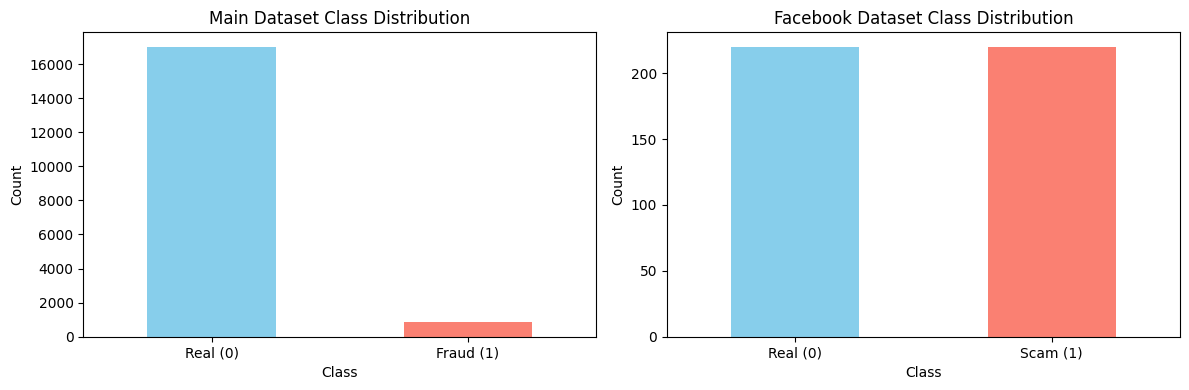

In [9]:
# class distribution for both datasets

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

data["fraudulent"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color=["skyblue", "salmon"]
)
axes[0].set_title("Main Dataset Class Distribution")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(["Real (0)", "Fraud (1)"], rotation=0)

fb_data["label"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color=["skyblue", "salmon"]
)
axes[1].set_title("Facebook Dataset Class Distribution")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")
axes[1].set_xticklabels(["Real (0)", "Scam (1)"], rotation=0)

plt.tight_layout()
plt.show()

## Step 3: Missing Value Analysis and Text Preparation

This step analyzes missing values in both datasets and prepares the textual input for machine learning. A unified text column is created for each dataset so that both can be used consistently in the modeling stage.


In [10]:
# Missing values count for both datasets

print("Missing values in main dataset:")
main_missing = data.isnull().sum().sort_values(ascending=False)
display(main_missing[main_missing > 0])

print("\nMissing values in Facebook dataset:")
fb_missing = fb_data.isnull().sum().sort_values(ascending=False)
display(fb_missing[fb_missing > 0])

Missing values in main dataset:


,0
salary_range,15012
department,11547
required_education,8105
benefits,7212
required_experience,7050
function,6455
industry,4903
employment_type,3471
company_profile,3308
requirements,2696



Missing values in Facebook dataset:


,0


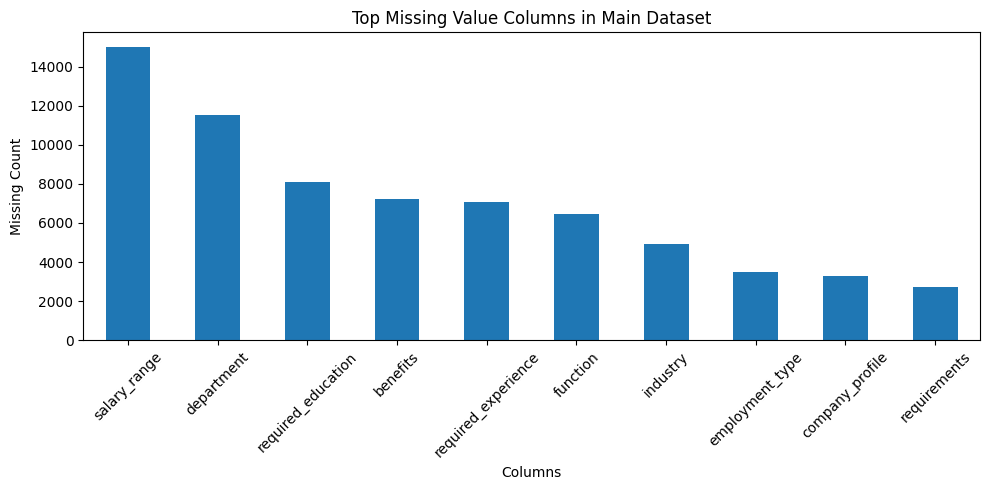

In [11]:
# Visualize top missing values in the main dataset

main_missing_nonzero = main_missing[main_missing > 0].head(10)

plt.figure(figsize=(10, 5))
main_missing_nonzero.plot(kind="bar")
plt.title("Top Missing Value Columns in Main Dataset")
plt.xlabel("Columns")
plt.ylabel("Missing Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
# Create clean text columns for both datasets

data["text"] = (
    data["title"].fillna("") + " " +
    data["description"].fillna("") + " " +
    data["requirements"].fillna("") + " " +
    data["company_profile"].fillna("") + " " +
    data["benefits"].fillna("")
)

fb_data["text"] = fb_data["post_text"].fillna("")

print("Text columns created successfully.\n")

print("Main dataset text preview:")
display(data[["text", "fraudulent"]].head())

print("Facebook dataset text preview:")
display(fb_data[["text", "label"]].head())

Text columns created successfully.

Main dataset text preview:


,text,fraudulent
0,"Marketing Intern Food52, a fast-growing, James...",0
1,Customer Service - Cloud Video Production Orga...,0
2,Commissioning Machinery Assistant (CMA) Our cl...,0
3,Account Executive - Washington DC THE COMPANY:...,0
4,Bill Review Manager JOB TITLE: Itemization Rev...,0


Facebook dataset text preview:


,text,label
0,ডাটা এন্ট্রি কাজ weekly income admin এর সাথে য...,1
1,Urban Retail Hub job circular for Junior Softw...,0
2,Apex Digital Services is hiring a Accounts Ass...,0
3,অভিজ্ঞতা ছাড়াই কাজ for students/housewife. sam...,1
4,Vacancy: Customer Support Executive at DeltaSo...,0


In [15]:
# Text length analysis

data["text_length"] = data["text"].apply(len)
fb_data["text_length"] = fb_data["text"].apply(len)

print("Main dataset text length summary:")
display(data["text_length"].describe())

print("\nFacebook dataset text length summary:")
display(fb_data["text_length"].describe())

Main dataset text length summary:


,text_length
count,17880.000000
mean,2670.464094
std,1465.514148
min,18.000000
25%,1595.000000
50%,2522.000000
75%,3475.000000
max,14945.000000



Facebook dataset text length summary:


,text_length
count,440.000000
mean,168.554545
std,49.000179
min,79.000000
25%,130.750000
50%,157.500000
75%,203.000000
max,323.000000


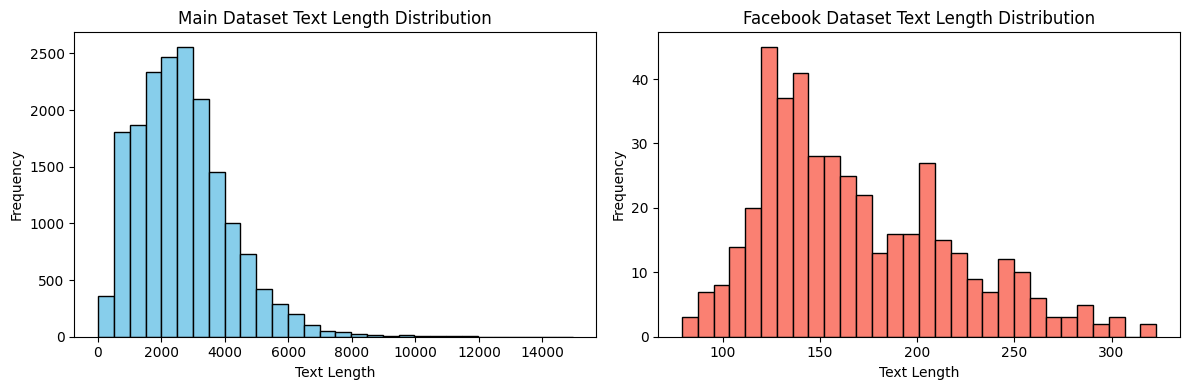

In [16]:
# Visual comparison of text length distribution

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(data["text_length"], bins=30, color="skyblue", edgecolor="black")
axes[0].set_title("Main Dataset Text Length Distribution")
axes[0].set_xlabel("Text Length")
axes[0].set_ylabel("Frequency")

axes[1].hist(fb_data["text_length"], bins=30, color="salmon", edgecolor="black")
axes[1].set_title("Facebook Dataset Text Length Distribution")
axes[1].set_xlabel("Text Length")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Step 4: Feature Extraction and Baseline Model Training

In this step, TF-IDF vectorization is applied to the textual data, and a baseline Logistic Regression model is trained using the main dataset. The goal is to establish an initial benchmark before testing cross-dataset performance.

In [17]:
# Step 4: TF-IDF feature extraction on main dataset

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X = tfidf.fit_transform(data["text"])
y = data["fraudulent"]

print("TF-IDF feature matrix shape:", X.shape)
print("Target shape:", y.shape)

TF-IDF feature matrix shape: (17880, 5000)
Target shape: (17880,)


In [18]:
# Train-test split for baseline model

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Training fraud distribution:")
print(y_train.value_counts())

print("\nTest fraud distribution:")
print(y_test.value_counts())

Training set shape: (14304, 5000)
Test set shape: (3576, 5000)
Training fraud distribution:
fraudulent
0    13611
1      693
Name: count, dtype: int64

Test fraud distribution:
fraudulent
0    3403
1     173
Name: count, dtype: int64


In [20]:
# Train Logistic Regression baseline model

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Baseline Logistic Regression model trained successfully.")

Baseline Logistic Regression model trained successfully.


In [21]:
from sklearn.metrics import accuracy_score, classification_report

lr_accuracy = accuracy_score(y_test, lr_pred)
print("Baseline Logistic Regression Accuracy:", lr_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred))

Baseline Logistic Regression Accuracy: 0.9728747203579419

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      3403
           1       1.00      0.44      0.61       173

    accuracy                           0.97      3576
   macro avg       0.99      0.72      0.80      3576
weighted avg       0.97      0.97      0.97      3576



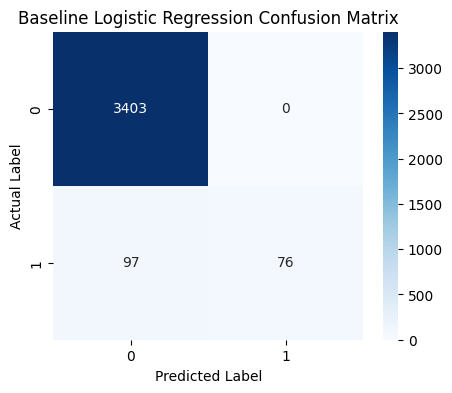

In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Baseline Logistic Regression Confusion Matrix")
plt.show()

,Metric,Score
0,Precision,1.000000
1,Recall,0.439306
2,F1-Score,0.610442


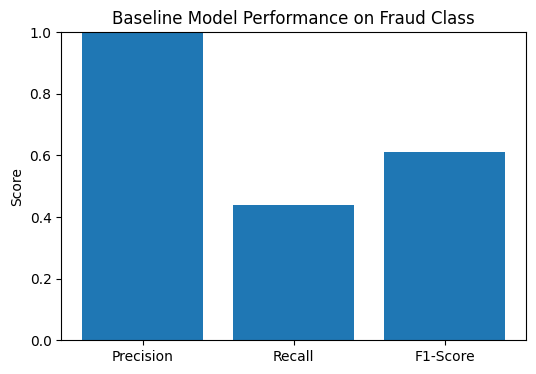

In [23]:
report_dict = classification_report(y_test, lr_pred, output_dict=True)

fraud_precision = report_dict["1"]["precision"]
fraud_recall = report_dict["1"]["recall"]
fraud_f1 = report_dict["1"]["f1-score"]

metrics_df = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-Score"],
    "Score": [fraud_precision, fraud_recall, fraud_f1]
})

display(metrics_df)

plt.figure(figsize=(6, 4))
plt.bar(metrics_df["Metric"], metrics_df["Score"])
plt.ylim(0, 1)
plt.title("Baseline Model Performance on Fraud Class")
plt.ylabel("Score")
plt.show()

## Step 5: Cross-Dataset Testing on Facebook Posts

In this step, the baseline Logistic Regression model trained on the main dataset is tested on the Facebook dataset. This helps evaluate whether a model trained on one domain can generalize to another domain with different language style and structure.

In [24]:
# Apply baseline TF-IDF + Logistic Regression model to Facebook dataset

fb_X = tfidf.transform(fb_data["text"])
fb_y = fb_data["label"]

fb_pred = lr_model.predict(fb_X)

print("Facebook feature matrix shape:", fb_X.shape)
print("Facebook target shape:", fb_y.shape)
print("Prediction completed successfully.")

Facebook feature matrix shape: (440, 5000)
Facebook target shape: (440,)
Prediction completed successfully.


In [25]:
# Evaluate baseline model on Facebook dataset

fb_accuracy = accuracy_score(fb_y, fb_pred)
print("Baseline Model Accuracy on Facebook Dataset:", fb_accuracy)

print("\nClassification Report on Facebook Dataset:\n")
print(classification_report(fb_y, fb_pred))

Baseline Model Accuracy on Facebook Dataset: 0.5

Classification Report on Facebook Dataset:

              precision    recall  f1-score   support

           0       0.50      1.00      0.67       220
           1       0.00      0.00      0.00       220

    accuracy                           0.50       440
   macro avg       0.25      0.50      0.33       440
weighted avg       0.25      0.50      0.33       440



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


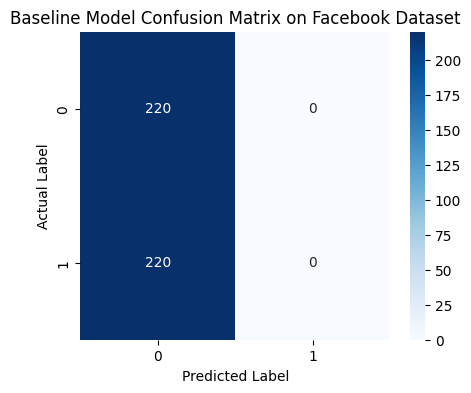

In [26]:
# Confusion matrix for Facebook dataset

fb_cm = confusion_matrix(fb_y, fb_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(fb_cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Baseline Model Confusion Matrix on Facebook Dataset")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Metric,Score
0,Precision,0.0
1,Recall,0.0
2,F1-Score,0.0


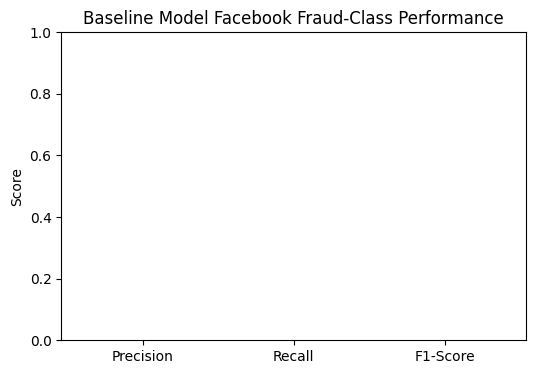

In [27]:
# Fraud-class metrics on Facebook dataset

fb_report_dict = classification_report(fb_y, fb_pred, output_dict=True)

fb_precision = fb_report_dict["1"]["precision"]
fb_recall = fb_report_dict["1"]["recall"]
fb_f1 = fb_report_dict["1"]["f1-score"]

fb_metrics_df = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-Score"],
    "Score": [fb_precision, fb_recall, fb_f1]
})

display(fb_metrics_df)

plt.figure(figsize=(6, 4))
plt.bar(fb_metrics_df["Metric"], fb_metrics_df["Score"])
plt.ylim(0, 1)
plt.title("Baseline Model Facebook Fraud-Class Performance")
plt.ylabel("Score")
plt.show()

## Step 6: Combined Dataset Training for Domain Adaptation

In this step, the main dataset and the Facebook dataset are combined to build a more robust model. This helps the classifier learn both formal job-post patterns and short mixed-language social media scam patterns.

In [28]:
# Combine both datasets into one unified dataset

combined_data = pd.concat([
    data[["text", "fraudulent"]].rename(columns={"fraudulent": "label"}),
    fb_data[["text", "label"]]
], ignore_index=True)

print("Combined dataset shape:", combined_data.shape)
print("\nCombined class distribution:")
print(combined_data["label"].value_counts())

display(combined_data.head())

Combined dataset shape: (18320, 2)

Combined class distribution:
label
0    17234
1     1086
Name: count, dtype: int64


,text,label
0,"Marketing Intern Food52, a fast-growing, James...",0
1,Customer Service - Cloud Video Production Orga...,0
2,Commissioning Machinery Assistant (CMA) Our cl...,0
3,Account Executive - Washington DC THE COMPANY:...,0
4,Bill Review Manager JOB TITLE: Itemization Rev...,0


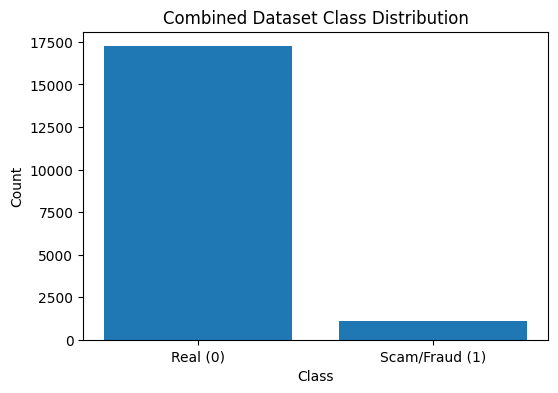

In [29]:
# Visualize combined class distribution

combined_counts = combined_data["label"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Real (0)", "Scam/Fraud (1)"], combined_counts.values)
plt.title("Combined Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [30]:
# Improved TF-IDF for mixed-domain text

tfidf2 = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2)
)

X2 = tfidf2.fit_transform(combined_data["text"])
y2 = combined_data["label"]

print("Improved TF-IDF feature matrix shape:", X2.shape)
print("Target shape:", y2.shape)

Improved TF-IDF feature matrix shape: (18320, 8000)
Target shape: (18320,)


In [31]:
# Train-test split on combined dataset

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

print("Combined training set shape:", X2_train.shape)
print("Combined test set shape:", X2_test.shape)

print("\nTraining class distribution:")
print(y2_train.value_counts())

print("\nTest class distribution:")
print(y2_test.value_counts())

Combined training set shape: (14656, 8000)
Combined test set shape: (3664, 8000)

Training class distribution:
label
0    13787
1      869
Name: count, dtype: int64

Test class distribution:
label
0    3447
1     217
Name: count, dtype: int64


In [32]:
# Train improved Logistic Regression model

improved_lr = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

improved_lr.fit(X2_train, y2_train)
improved_pred = improved_lr.predict(X2_test)

print("Improved Logistic Regression model trained successfully.")

Improved Logistic Regression model trained successfully.


In [33]:
# Train improved Logistic Regression model

improved_lr = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

improved_lr.fit(X2_train, y2_train)
improved_pred = improved_lr.predict(X2_test)

print("Improved Logistic Regression model trained successfully.")

Improved Logistic Regression model trained successfully.


In [34]:
# Evaluate improved model

improved_accuracy = accuracy_score(y2_test, improved_pred)
print("Improved Logistic Regression Accuracy:", improved_accuracy)

print("\nClassification Report:\n")
print(classification_report(y2_test, improved_pred, zero_division=0))

Improved Logistic Regression Accuracy: 0.9735262008733624

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3447
           1       0.73      0.88      0.80       217

    accuracy                           0.97      3664
   macro avg       0.86      0.93      0.89      3664
weighted avg       0.98      0.97      0.97      3664



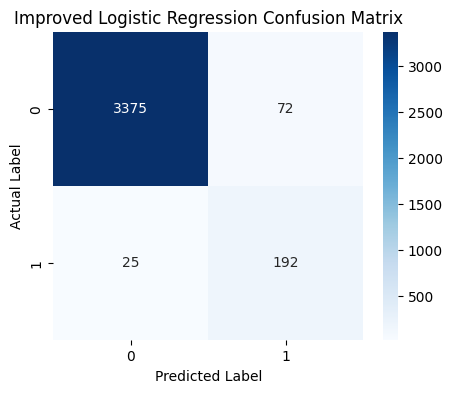

In [35]:
# Confusion matrix for improved model

improved_cm = confusion_matrix(y2_test, improved_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(improved_cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Improved Logistic Regression Confusion Matrix")
plt.show()

,Metric,Score
0,Precision,0.727273
1,Recall,0.884793
2,F1-Score,0.798337


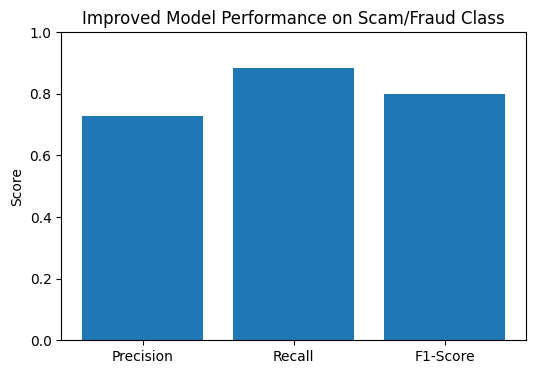

In [36]:
# Fraud/scam class metrics for improved model

improved_report = classification_report(y2_test, improved_pred, output_dict=True, zero_division=0)

improved_precision = improved_report["1"]["precision"]
improved_recall = improved_report["1"]["recall"]
improved_f1 = improved_report["1"]["f1-score"]

improved_metrics_df = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-Score"],
    "Score": [improved_precision, improved_recall, improved_f1]
})

display(improved_metrics_df)

plt.figure(figsize=(6, 4))
plt.bar(improved_metrics_df["Metric"], improved_metrics_df["Score"])
plt.ylim(0, 1)
plt.title("Improved Model Performance on Scam/Fraud Class")
plt.ylabel("Score")
plt.show()

## Step 7: Strict Facebook-Only Final Evaluation

To perform a more realistic evaluation, the Facebook dataset is split into separate training and testing portions. The final model is trained using the main dataset plus only the Facebook training subset, and then evaluated on unseen Facebook test posts.

In [37]:
# Split Facebook dataset into train and test sets

fb_train, fb_test = train_test_split(
    fb_data,
    test_size=0.2,
    random_state=42,
    stratify=fb_data["label"]
)

print("Facebook training shape:", fb_train.shape)
print("Facebook test shape:", fb_test.shape)

print("\nFacebook train class distribution:")
print(fb_train["label"].value_counts())

print("\nFacebook test class distribution:")
print(fb_test["label"].value_counts())

Facebook training shape: (352, 17)
Facebook test shape: (88, 17)

Facebook train class distribution:
label
1    176
0    176
Name: count, dtype: int64

Facebook test class distribution:
label
1    44
0    44
Name: count, dtype: int64


In [38]:
# Create final training dataset: main dataset + Facebook-train only

final_train_data = pd.concat([
    data[["text", "fraudulent"]].rename(columns={"fraudulent": "label"}),
    fb_train[["text", "label"]]
], ignore_index=True)

print("Final training dataset shape:", final_train_data.shape)
print("\nFinal training class distribution:")
print(final_train_data["label"].value_counts())

Final training dataset shape: (18232, 2)

Final training class distribution:
label
0    17190
1     1042
Name: count, dtype: int64


In [39]:
# TF-IDF for final training setup

tfidf3 = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2)
)

X3_train = tfidf3.fit_transform(final_train_data["text"])
y3_train = final_train_data["label"]

X3_test_fb = tfidf3.transform(fb_test["text"])
y3_test_fb = fb_test["label"]

print("Final train feature shape:", X3_train.shape)
print("Facebook-only test feature shape:", X3_test_fb.shape)

Final train feature shape: (18232, 8000)
Facebook-only test feature shape: (88, 8000)


In [40]:
# Train final Logistic Regression model

final_lr = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

final_lr.fit(X3_train, y3_train)
final_lr_pred = final_lr.predict(X3_test_fb)

print("Final Logistic Regression model trained successfully.")

Final Logistic Regression model trained successfully.


In [41]:
# Evaluate final model on unseen Facebook test set

final_fb_accuracy = accuracy_score(y3_test_fb, final_lr_pred)
print("Final Facebook-only Test Accuracy:", final_fb_accuracy)

print("\nClassification Report:\n")
print(classification_report(y3_test_fb, final_lr_pred, zero_division=0))

Final Facebook-only Test Accuracy: 0.9659090909090909

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        44
           1       0.94      1.00      0.97        44

    accuracy                           0.97        88
   macro avg       0.97      0.97      0.97        88
weighted avg       0.97      0.97      0.97        88



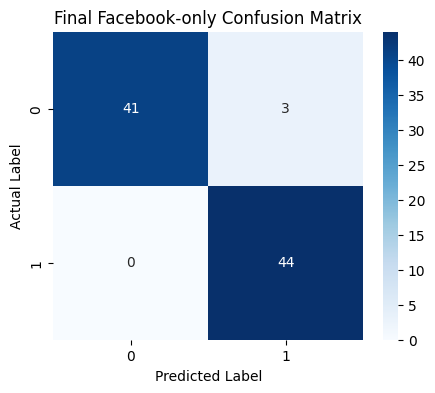

In [42]:
# Confusion matrix for final Facebook-only test

final_fb_cm = confusion_matrix(y3_test_fb, final_lr_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(final_fb_cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Final Facebook-only Confusion Matrix")
plt.show()

,Metric,Score
0,Precision,0.936170
1,Recall,1.000000
2,F1-Score,0.967033


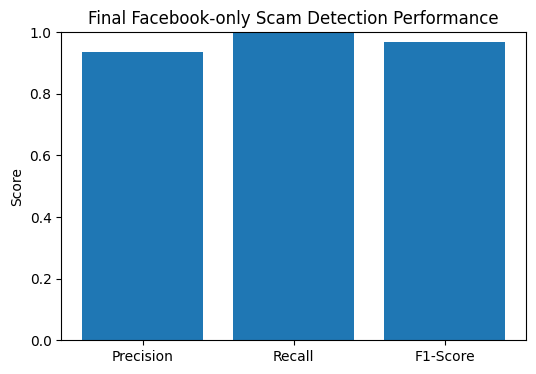

In [43]:
# Fraud/scam metrics for final Facebook-only test

final_fb_report = classification_report(
    y3_test_fb,
    final_lr_pred,
    output_dict=True,
    zero_division=0
)

final_fb_precision = final_fb_report["1"]["precision"]
final_fb_recall = final_fb_report["1"]["recall"]
final_fb_f1 = final_fb_report["1"]["f1-score"]

final_fb_metrics_df = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-Score"],
    "Score": [final_fb_precision, final_fb_recall, final_fb_f1]
})

display(final_fb_metrics_df)

plt.figure(figsize=(6, 4))
plt.bar(final_fb_metrics_df["Metric"], final_fb_metrics_df["Score"])
plt.ylim(0, 1)
plt.title("Final Facebook-only Scam Detection Performance")
plt.ylabel("Score")
plt.show()

In [45]:
# Preview final predictions on unseen Facebook test posts

final_fb_results = fb_test.copy()
final_fb_results["predicted_label"] = final_lr_pred
final_fb_results["predicted_class"] = final_fb_results["predicted_label"].map({
    0: "Real Job",
    1: "Fake Job Scam"
})

display(final_fb_results[["text", "label", "predicted_label", "predicted_class"]].head(10))

,text,label,predicted_label,predicted_class
287,মোবাইল দিয়ে কাজ ২-৩ ঘন্টা কাজ Telegram এ msg দ...,1,1,Fake Job Scam
164,Apex Digital Services job circular for Content...,0,0,Real Job
382,We are looking for a Digital Marketing Executi...,0,0,Real Job
364,📲 অনলাইন জব! no experience needed. inbox now. ...,1,1,Fake Job Scam
265,Greenfield Apparels is hiring a Graphic Design...,0,0,Real Job
228,Apex Digital Services job circular for Junior ...,0,0,Real Job
370,"ডাটা এন্ট্রি কাজ — same day start, Telegram এ ...",1,1,Fake Job Scam
162,অভিজ্ঞতা ছাড়াই কাজ for students/housewife. sam...,1,1,Fake Job Scam
246,ডাটা এন্ট্রি কাজ available বাংলাদেশ থেকে করা য...,1,1,Fake Job Scam
156,বাসায় বসে income সপ্তাহে payout inbox now secu...,1,1,Fake Job Scam


## Step 8: Final Model Comparison on Unseen Facebook Test Data

In this step, multiple machine learning algorithms are trained and evaluated on the same final training data. Their performances are compared on the unseen Facebook test set to determine the most effective model for scam detection.

In [46]:
# Train SVM model on final training data

from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight="balanced",
    max_iter=5000
)

svm_model.fit(X3_train, y3_train)
svm_pred = svm_model.predict(X3_test_fb)

print("SVM model trained successfully.")

SVM model trained successfully.


In [47]:
# Evaluate SVM on unseen Facebook test set

svm_accuracy = accuracy_score(y3_test_fb, svm_pred)
print("SVM Facebook-only Test Accuracy:", svm_accuracy)

print("\nSVM Classification Report:\n")
print(classification_report(y3_test_fb, svm_pred, zero_division=0))

SVM Facebook-only Test Accuracy: 1.0

SVM Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        44
           1       1.00      1.00      1.00        44

    accuracy                           1.00        88
   macro avg       1.00      1.00      1.00        88
weighted avg       1.00      1.00      1.00        88



In [48]:
# Train Random Forest model on final training data

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X3_train, y3_train)
rf_pred = rf_model.predict(X3_test_fb)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [49]:
# Evaluate Random Forest on unseen Facebook test set

rf_accuracy = accuracy_score(y3_test_fb, rf_pred)
print("Random Forest Facebook-only Test Accuracy:", rf_accuracy)

print("\nRandom Forest Classification Report:\n")
print(classification_report(y3_test_fb, rf_pred, zero_division=0))

Random Forest Facebook-only Test Accuracy: 1.0

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        44
           1       1.00      1.00      1.00        44

    accuracy                           1.00        88
   macro avg       1.00      1.00      1.00        88
weighted avg       1.00      1.00      1.00        88



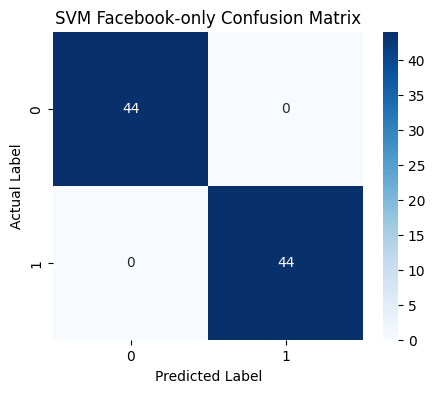

In [50]:
# Confusion matrix for SVM

svm_cm = confusion_matrix(y3_test_fb, svm_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(svm_cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("SVM Facebook-only Confusion Matrix")
plt.show()

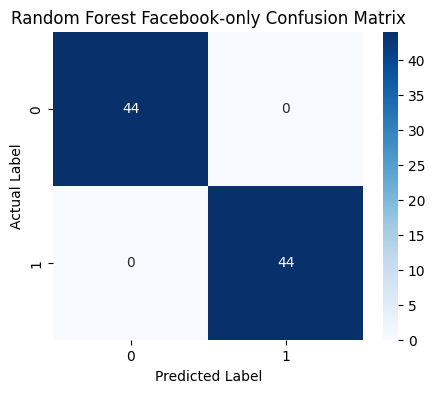

In [51]:
# Confusion matrix for Random Forest

rf_cm = confusion_matrix(y3_test_fb, rf_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Random Forest Facebook-only Confusion Matrix")
plt.show()

In [52]:
# Compare final models in one table

lr_report = classification_report(y3_test_fb, final_lr_pred, output_dict=True, zero_division=0)
svm_report = classification_report(y3_test_fb, svm_pred, output_dict=True, zero_division=0)
rf_report = classification_report(y3_test_fb, rf_pred, output_dict=True, zero_division=0)

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Random Forest"],
    "Accuracy": [
        accuracy_score(y3_test_fb, final_lr_pred),
        accuracy_score(y3_test_fb, svm_pred),
        accuracy_score(y3_test_fb, rf_pred)
    ],
    "Precision (Scam)": [
        lr_report["1"]["precision"],
        svm_report["1"]["precision"],
        rf_report["1"]["precision"]
    ],
    "Recall (Scam)": [
        lr_report["1"]["recall"],
        svm_report["1"]["recall"],
        rf_report["1"]["recall"]
    ],
    "F1-Score (Scam)": [
        lr_report["1"]["f1-score"],
        svm_report["1"]["f1-score"],
        rf_report["1"]["f1-score"]
    ]
})

display(comparison_df)

,Model,Accuracy,Precision (Scam),Recall (Scam),F1-Score (Scam)
0,Logistic Regression,0.965909,0.93617,1.0,0.967033
1,SVM,1.000000,1.00000,1.0,1.000000
2,Random Forest,1.000000,1.00000,1.0,1.000000


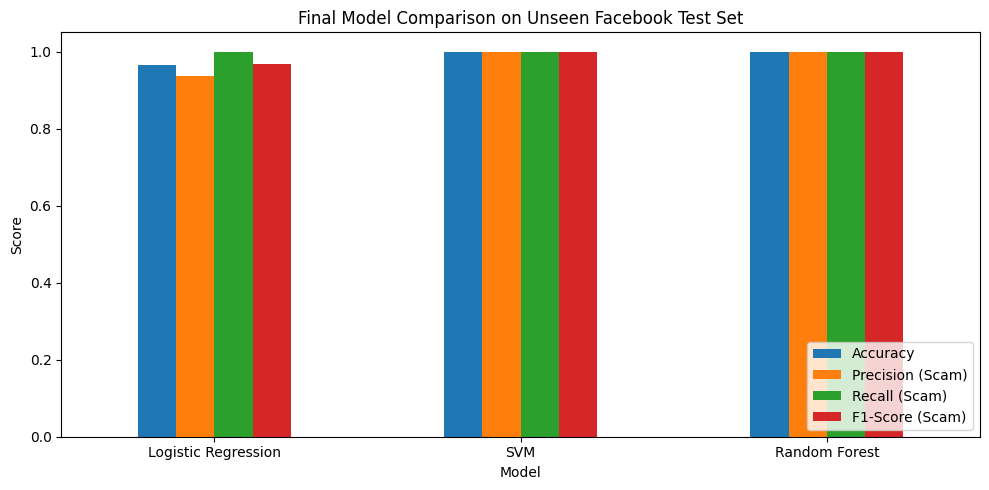

In [53]:
# Visual comparison of final model performance

comparison_plot = comparison_df.set_index("Model")

comparison_plot.plot(kind="bar", figsize=(10, 5))
plt.title("Final Model Comparison on Unseen Facebook Test Set")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [54]:
# Step 9: Save final best model (SVM) and TF-IDF vectorizer

import pickle
import os

with open("best_svm_model.pkl", "wb") as f:
    pickle.dump(svm_model, f)

with open("final_tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf3, f)

print("Saved files successfully:")
print("- best_svm_model.pkl")
print("- final_tfidf_vectorizer.pkl")

print("\nCurrent working directory files:")
print(os.listdir())

Saved files successfully:
- best_svm_model.pkl
- final_tfidf_vectorizer.pkl

Current working directory files:
['.config', 'drive', 'final_tfidf_vectorizer.pkl', 'fake_job_postings.csv', 'best_svm_model.pkl', 'fb_job_post_dataset.csv', 'sample_data']


In [56]:
# Step 10: Export thesis result files

# 1) Save final Facebook-only prediction results
final_fb_results.to_csv("final_facebook_test_results.csv", index=False)

# 2) Save model comparison table
comparison_df.to_csv("model_comparison_results.csv", index=False)

# 3) Save main summary table
summary_df = pd.DataFrame({
    "Experiment": [
        "Baseline Logistic Regression on Main Dataset",
        "Baseline Model on Facebook Dataset",
        "Improved Logistic Regression on Combined Dataset",
        "Final Logistic Regression on Unseen Facebook Test",
        "Final SVM on Unseen Facebook Test",
        "Final Random Forest on Unseen Facebook Test"
    ],
    "Accuracy": [
        lr_accuracy,
        fb_accuracy,
        improved_accuracy,
        final_fb_accuracy,
        svm_accuracy,
        rf_accuracy
    ]
})

summary_df.to_csv("experiment_summary_results.csv", index=False)

print("Exported files successfully:")
print("- final_facebook_test_results.csv")
print("- model_comparison_results.csv")
print("- experiment_summary_results.csv")

Exported files successfully:
- final_facebook_test_results.csv
- model_comparison_results.csv
- experiment_summary_results.csv


In [57]:
from google.colab import files

files.download("best_svm_model.pkl")
files.download("final_tfidf_vectorizer.pkl")
files.download("final_facebook_test_results.csv")
files.download("model_comparison_results.csv")
files.download("experiment_summary_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>